##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [1]:
!pip install -q keras-cv tensorflow matplotlib pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 11.7 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 41.4 MB/s eta 0:00:00


[SKIP] https://en.wikipedia.org/wiki/Puppy#/media/File:Cara_de_quem_caiu_do_caminh%C3%A3o..._(cropped).jpg
       -> UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x791fd0a6e4d0>
[SKIP] https://upload.wikimedia.org/wikipedia/commons/4/4a/Bicycle_in_Amsterdam.jpg
       -> HTTPError: HTTP Error 404: Not Found
Downloaded: 3 images
Used samples:
- person -> https://upload.wikimedia.org/wikipedia/commons/b/b4/12_years_boy_from_Chanderi_%283%29.jpg
- car -> https://upload.wikimedia.org/wikipedia/commons/b/bd/Kilowatt.jpg
- cat -> https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg


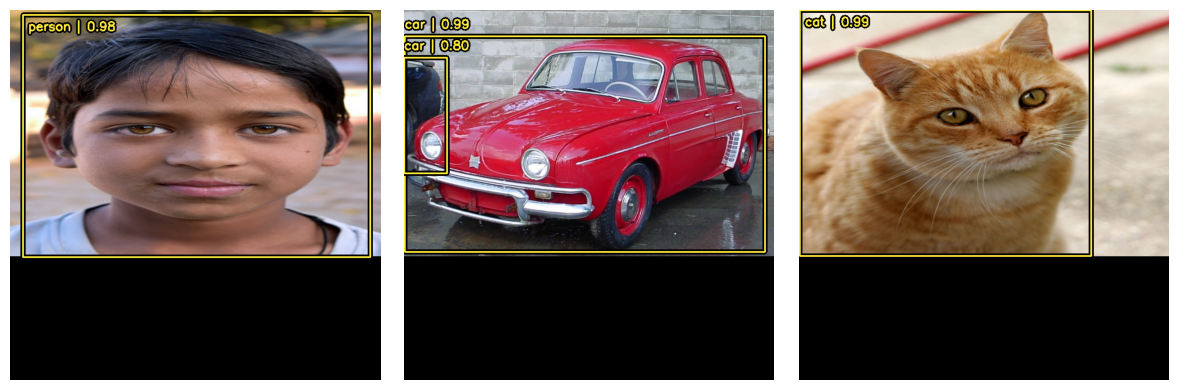


Top detections per image (conf >= 0.25):

Image 1 (True label you chose: person):
  - person: 0.975

Image 2 (True label you chose: car):
  - car: 0.990
  - car: 0.796

Image 3 (True label you chose: cat):
  - cat: 0.991


In [19]:
from PIL import Image
from urllib.request import Request, urlopen
from urllib.error import HTTPError, URLError
from io import BytesIO

VOC_CLASS_NAMES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor",
]


detector = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh",
)

def download_image(url: str, size=(900, 600)) -> np.ndarray | None:
    """Download image -> RGB -> resize fixed for batching. Return None if fails."""
    try:
        headers = {"User-Agent": "Mozilla/5.0"}
        req = Request(url, headers=headers)
        data = urlopen(req, timeout=60).read()
        img = Image.open(BytesIO(data)).convert("RGB")
        img = img.resize(size, Image.Resampling.LANCZOS)
        return np.array(img, dtype=np.uint8)
    except (HTTPError, URLError, TimeoutError, OSError) as e:
        print(f"[SKIP] {url}\n       -> {type(e).__name__}: {e}")
        return None

# 2) 5 images (VOC-like classes)
samples = [
    {"true_label": "person",  "url": "https://upload.wikimedia.org/wikipedia/commons/b/b4/12_years_boy_from_Chanderi_%283%29.jpg"},
    {"true_label": "dog",     "url": "https://en.wikipedia.org/wiki/Puppy#/media/File:Cara_de_quem_caiu_do_caminh%C3%A3o..._(cropped).jpg"},
    {"true_label": "car",     "url": "https://upload.wikimedia.org/wikipedia/commons/b/bd/Kilowatt.jpg"},
    {"true_label": "bicycle", "url": "https://upload.wikimedia.org/wikipedia/commons/4/4a/Bicycle_in_Amsterdam.jpg"},
    {"true_label": "cat",     "url": "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg"},
]

images_list, good_samples = [], []

for s in samples:
    arr = download_image(s["url"], size=(900, 600))
    if arr is not None:
        images_list.append(arr)
        good_samples.append(s)

if len(images_list) < 1:
    raise RuntimeError("No images downloaded. Replace URLs with valid direct image links.")

images_np = np.stack(images_list, axis=0)
print("Downloaded:", len(images_list), "images")
print("Used samples:")
for s in good_samples:
    print("-", s["true_label"], "->", s["url"])

# Resize before inference (as required)
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)
images_resized = inference_resizing(tf.convert_to_tensor(images_np))

# Predict
predictions = detector.predict(images_resized, verbose=0)

# Visualize
keras_cv.visualization.plot_bounding_box_gallery(
    images_resized,
    value_range=(0, 255),
    y_pred=predictions,
    bounding_box_format="xywh",
    class_mapping=dict(enumerate(VOC_CLASS_NAMES)),
    rows=1,
    cols=min(5, len(images_list)),
    scale=4,
    font_scale=0.7,
    show=True,
)

# Print top detections per image 
print("\nTop detections per image (conf >= 0.25):")
for i, s in enumerate(good_samples):
    boxes = np.array(predictions["boxes"][i])
    classes = np.array(predictions["classes"][i]).astype(int)
    conf = np.array(predictions["confidence"][i])

    keep = conf >= 0.25
    classes, conf = classes[keep], conf[keep]

    # top 5 by confidence
    order = np.argsort(-conf)[:5]
    classes, conf = classes[order], conf[order]

    print(f"\nImage {i+1} (True label you chose: {s['true_label']}):")
    if len(conf) == 0:
        print("  - No detections above threshold.")
    else:
        for c, sc in zip(classes, conf):
            name = VOC_CLASS_NAMES[c] if 0 <= c < len(VOC_CLASS_NAMES) else str(c)
            print(f"  - {name}: {sc:.3f}")